## **Modelos Deep Learning em PyTorch**

**Tarefa 3 do Trabalho Prático — Aprendizagem Profunda**

1. **Stratified K-Fold (K=5)** — Comparação robusta de modelos
2. **DNN Bottleneck / BatchNorm** — Features tabulares (TF-IDF)
3. **Embedding + DNN** — Embedding treinável sobre sequências
4. **BiLSTM / BiLSTM+GloVe** — LSTM bidirecional
5. **Retreino do melhor modelo** e avaliação final no dataset do professor

### **1. Imports e Configuração**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os, time, re
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report

sys.path.append(os.path.abspath('../src'))
from utils import (prepare_text_data, prepare_fold_data, transform_new_texts,
                    clean_text, stratified_k_fold)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

Dispositivo: cuda


### **2. Carregamento dos Dados**

In [2]:
print('A carregar os datasets...')

df_main = pd.read_csv('../data/dataset.csv', sep=';')
df_main.columns = df_main.columns.str.lower()
textos = df_main['text'].tolist()
labels = df_main['label'].tolist()

df_test = pd.read_csv('../data/raw/dataset-exemplos.csv', sep=';')
df_test.columns = df_test.columns.str.lower()
textos_test = df_test['text'].tolist()
labels_test = df_test['label'].tolist()

class_names_list = sorted(set(labels))
num_classes = len(class_names_list)

print(f'  Dataset principal: {len(textos)} textos')
print(f'  Dataset teste (prof): {len(textos_test)} textos')
print(f'  Classes: {class_names_list}')

A carregar os datasets...
  Dataset principal: 5000 textos
  Dataset teste (prof): 125 textos
  Classes: ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']


### **3. Definição dos Modelos**

| Modelo | Tipo | Input |
|--------|------|-------|
| **DNN BatchNorm** | Feedforward | TF-IDF tabular |
| **DNN Bottleneck** | Feedforward | TF-IDF tabular |
| **Embedding + DNN** | Embedding → Dense | Sequências |
| **BiLSTM** | Embedding → LSTM | Sequências |
| **BiLSTM + GloVe** | Embedding → LSTM | Sequências + GloVe pré-treinado |

In [3]:
class DNNBatchNorm(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, num_classes))
    def forward(self, x): return self.net(x)

class DNNBottleneck(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(32, num_classes))
    def forward(self, x): return self.net(x)

class EmbeddingDNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.net = nn.Sequential(
            nn.Linear(embed_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, num_classes))
    def forward(self, x):
        embedded = self.embedding(x)
        mask = (x != 0).unsqueeze(-1).float()
        pooled = (embedded * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        return self.net(pooled)

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        combined = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.fc(self.dropout(combined))

class BiLSTMGloVe(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_classes,
                 num_layers=2, dropout=0.3, freeze_embed=True):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=freeze_embed, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, num_classes))
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        combined = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.fc(self.dropout(combined))

print('Modelos definidos.')

Modelos definidos.


### **4. Validação Cruzada — Stratified K-Fold (K=5)**

Para cada fold, o TF-IDF e os vocabulários são ajustados apenas no treino desse fold.
Reportamos média ± desvio padrão da accuracy.

In [4]:
K = 5
FEAT_PARAMS = dict(max_features=1500, char_features=1500, ngram_range=(1, 2), stop_words=set())
EMBED_DIM = 64
HIDDEN_DIM = 64
HIDDEN_DIM_GLOVE = 128
GLOVE_DIM = 100
MAX_SEQ_LEN = 150
VOCAB_SIZE = 10000

def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return [t for t in text.split() if len(t) > 1]

def texts_to_sequences(texts, word2idx, max_len):
    sequences = []
    for text in texts:
        tokens = simple_tokenize(text)
        seq = [word2idx.get(t, 1) for t in tokens[:max_len]]
        seq = seq + [0] * (max_len - len(seq))
        sequences.append(seq)
    return np.array(sequences)

def train_pytorch_model(model, X_train, y_train, X_val, y_val,
                        epochs=100, lr=0.001, wd=1e-3, patience=10, bs=128):
    '"""Treina um modelo PyTorch e retorna val accuracy."""'
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5)

    train_ds = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)

    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        for bx, by in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_out = model(X_val)
            val_loss = criterion(val_out, y_val).item()

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience: break

    if best_state: model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        acc = (torch.argmax(model(X_val), 1) == y_val).float().mean().item()
    return acc

print('Funções auxiliares definidas.')

Funções auxiliares definidas.


In [5]:
# ── Carregar GloVe (para BiLSTM+GloVe) ──
import zipfile, urllib.request

GLOVE_DIR = '../data/glove'
GLOVE_PATH = os.path.join(GLOVE_DIR, f'glove.6B.{GLOVE_DIM}d.txt')

if not os.path.exists(GLOVE_PATH):
    os.makedirs(GLOVE_DIR, exist_ok=True)
    zip_path = os.path.join(GLOVE_DIR, 'glove.6B.zip')
    if not os.path.exists(zip_path):
        print('A descarregar GloVe 6B (822MB)...')
        urllib.request.urlretrieve('https://nlp.stanford.edu/data/glove.6B.zip', zip_path)
    print('A extrair...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extract(f'glove.6B.{GLOVE_DIM}d.txt', GLOVE_DIR)
else:
    print(f'GloVe já disponível em {GLOVE_PATH}')

# Carregar TODOS os vetores GloVe (filtraremos por fold depois)
print(f'A carregar GloVe {GLOVE_DIM}d...')
glove_all = {}
with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        glove_all[parts[0]] = np.array(parts[1:], dtype=np.float32)
print(f'✅ GloVe carregado: {len(glove_all)} vetores')

def build_embedding_matrix(word2idx, glove_vectors, dim):
    """Constrói matriz de embeddings a partir do vocabulário e GloVe."""
    matrix = np.random.normal(scale=0.6, size=(len(word2idx), dim))
    matrix[0] = np.zeros(dim)  # padding
    found = 0
    for word, idx in word2idx.items():
        if word in glove_vectors:
            matrix[idx] = glove_vectors[word]
            found += 1
    print(f'    GloVe cobertura: {found}/{len(word2idx)-2} ({found/(len(word2idx)-2)*100:.0f}%)')
    return matrix


GloVe já disponível em ../data/glove\glove.6B.100d.txt
A carregar GloVe 100d...
✅ GloVe carregado: 400000 vetores


In [6]:
print("=" * 60)
print("Stratified 5-Fold Cross-Validation")
print("=" * 60)

cv_results = {}

# ── Modelos tabulares ──
tab_models = {
    'DNN BatchNorm': lambda inp, nc: DNNBatchNorm(inp, nc),
    'DNN Bottleneck': lambda inp, nc: DNNBottleneck(inp, nc),
}

for nome, model_fn in tab_models.items():
    print(f'\n{nome}:')
    accs = []
    for fold, (tr_idx, vl_idx) in enumerate(stratified_k_fold(labels, K)):
        texts_tr = [textos[i] for i in tr_idx]
        texts_vl = [textos[i] for i in vl_idx]
        labels_tr = [labels[i] for i in tr_idx]
        labels_vl = [labels[i] for i in vl_idx]

        X_tr, _, X_vl, _, _, enc = prepare_fold_data(
            texts_tr, labels_tr, texts_vl, labels_vl, **FEAT_PARAMS)
        y_tr = np.array([class_names_list.index(l) for l in labels_tr])
        y_vl = np.array([class_names_list.index(l) for l in labels_vl])

        torch.manual_seed(42)
        model = model_fn(X_tr.shape[1], num_classes)
        acc = train_pytorch_model(
            model,
            torch.FloatTensor(X_tr).to(device), torch.LongTensor(y_tr).to(device),
            torch.FloatTensor(X_vl).to(device), torch.LongTensor(y_vl).to(device),
        )
        accs.append(acc)
        print(f'  Fold {fold+1}: {acc:.2%}')
    cv_results[nome] = np.array(accs)
    print(f'  → Média: {np.mean(accs):.2%} ± {np.std(accs):.2%}')

# ── Modelos sequenciais ──
seq_model_configs = {
    'Embedding + DNN': ('embed', {}),
    'BiLSTM': ('bilstm', {}),
}

for nome, (mtype, _) in seq_model_configs.items():
    print(f'\n{nome}:')
    accs = []
    for fold, (tr_idx, vl_idx) in enumerate(stratified_k_fold(labels, K)):
        texts_tr = [textos[i] for i in tr_idx]
        texts_vl = [textos[i] for i in vl_idx]
        labels_tr = [labels[i] for i in tr_idx]
        labels_vl = [labels[i] for i in vl_idx]

        # Build vocab from fold train
        wc = Counter()
        for t in texts_tr: wc.update(simple_tokenize(t))
        mc = wc.most_common(VOCAB_SIZE - 2)
        w2i = {w: idx+2 for idx, (w, _) in enumerate(mc)}
        w2i['<PAD>'] = 0; w2i['<UNK>'] = 1
        vs = len(w2i)

        s_tr = texts_to_sequences(texts_tr, w2i, MAX_SEQ_LEN)
        s_vl = texts_to_sequences(texts_vl, w2i, MAX_SEQ_LEN)
        y_tr = np.array([class_names_list.index(l) for l in labels_tr])
        y_vl = np.array([class_names_list.index(l) for l in labels_vl])

        torch.manual_seed(42)
        if mtype == 'embed':
            model = EmbeddingDNN(vs, EMBED_DIM, num_classes)
        else:
            model = BiLSTM(vs, EMBED_DIM, HIDDEN_DIM, num_classes)

        acc = train_pytorch_model(
            model,
            torch.LongTensor(s_tr).to(device), torch.LongTensor(y_tr).to(device),
            torch.LongTensor(s_vl).to(device), torch.LongTensor(y_vl).to(device),
            wd=1e-4, patience=10
        )
        accs.append(acc)
        print(f'  Fold {fold+1}: {acc:.2%}')
    cv_results[nome] = np.array(accs)
    print(f'  → Média: {np.mean(accs):.2%} ± {np.std(accs):.2%}')

# ── BiLSTM + GloVe (embedding pré-treinado) ──
print(f'\nBiLSTM + GloVe:')
accs = []
for fold, (tr_idx, vl_idx) in enumerate(stratified_k_fold(labels, K)):
    texts_tr = [textos[i] for i in tr_idx]
    texts_vl = [textos[i] for i in vl_idx]
    labels_tr = [labels[i] for i in tr_idx]
    labels_vl = [labels[i] for i in vl_idx]

    # Build vocab from fold train
    wc = Counter()
    for t in texts_tr: wc.update(simple_tokenize(t))
    mc = wc.most_common(VOCAB_SIZE - 2)
    w2i = {w: idx+2 for idx, (w, _) in enumerate(mc)}
    w2i['<PAD>'] = 0; w2i['<UNK>'] = 1

    # Build GloVe embedding matrix for this fold's vocab
    emb_matrix = build_embedding_matrix(w2i, glove_all, GLOVE_DIM)

    s_tr = texts_to_sequences(texts_tr, w2i, MAX_SEQ_LEN)
    s_vl = texts_to_sequences(texts_vl, w2i, MAX_SEQ_LEN)
    y_tr = np.array([class_names_list.index(l) for l in labels_tr])
    y_vl = np.array([class_names_list.index(l) for l in labels_vl])

    torch.manual_seed(42)
    model = BiLSTMGloVe(emb_matrix, HIDDEN_DIM_GLOVE, num_classes, freeze_embed=True)
    acc = train_pytorch_model(
        model,
        torch.LongTensor(s_tr).to(device), torch.LongTensor(y_tr).to(device),
        torch.LongTensor(s_vl).to(device), torch.LongTensor(y_vl).to(device),
        wd=1e-4, patience=15
    )
    accs.append(acc)
    print(f'  Fold {fold+1}: {acc:.2%}')
cv_results['BiLSTM + GloVe'] = np.array(accs)
print(f'  → Média: {np.mean(accs):.2%} ± {np.std(accs):.2%}')


Stratified 5-Fold Cross-Validation

DNN BatchNorm:
  Fold 1: 84.10%
  Fold 2: 84.50%
  Fold 3: 85.80%
  Fold 4: 84.70%
  Fold 5: 83.40%
  → Média: 84.50% ± 0.79%

DNN Bottleneck:
  Fold 1: 83.80%
  Fold 2: 82.90%
  Fold 3: 85.90%
  Fold 4: 84.10%
  Fold 5: 85.40%
  → Média: 84.42% ± 1.09%

Embedding + DNN:
  Fold 1: 70.30%
  Fold 2: 69.70%
  Fold 3: 67.90%
  Fold 4: 71.50%
  Fold 5: 68.90%
  → Média: 69.66% ± 1.22%

BiLSTM:
  Fold 1: 57.70%
  Fold 2: 60.40%
  Fold 3: 66.10%
  Fold 4: 61.60%
  Fold 5: 56.40%
  → Média: 60.44% ± 3.38%

BiLSTM + GloVe:
    GloVe cobertura: 9722/9998 (97%)
  Fold 1: 61.60%
    GloVe cobertura: 9730/9998 (97%)
  Fold 2: 71.80%
    GloVe cobertura: 9728/9998 (97%)
  Fold 3: 73.50%
    GloVe cobertura: 9737/9998 (97%)
  Fold 4: 73.10%
    GloVe cobertura: 9726/9998 (97%)
  Fold 5: 68.40%
  → Média: 69.68% ± 4.42%


In [7]:
rows = []
for nome, accs in cv_results.items():
    rows.append({'Modelo': nome, 'Média': f'{accs.mean():.2%}',
                 'Std': f'±{accs.std():.2%}',
                 'Min': f'{accs.min():.2%}', 'Max': f'{accs.max():.2%}'})

df_cv = pd.DataFrame(rows).sort_values('Média', ascending=False)
print('\n' + '=' * 60)
print('RESUMO K-FOLD CV')
print('=' * 60)
print(df_cv.to_string(index=False))


RESUMO K-FOLD CV
         Modelo  Média    Std    Min    Max
  DNN BatchNorm 84.50% ±0.79% 83.40% 85.80%
 DNN Bottleneck 84.42% ±1.09% 82.90% 85.90%
 BiLSTM + GloVe 69.68% ±4.42% 61.60% 73.50%
Embedding + DNN 69.66% ±1.22% 67.90% 71.50%
         BiLSTM 60.44% ±3.38% 56.40% 66.10%


### **5. Retreino do Melhor Modelo + Avaliação no Teste**

Retreinamos o melhor modelo pelo K-Fold com split 80/20 para early stopping,
e avaliamos no dataset do professor (125 textos).

In [8]:
# Preparar dados com split interno
X_train, Y_train_oh, X_val, Y_val_oh, transformers, encoder = prepare_text_data(
    textos, labels,
    max_features=1500, char_features=1500, val_size=0.20,
    use_stratify=True, ngram_range=(1, 2), stop_words=set()
)
X_test = transform_new_texts(textos_test, transformers)
Y_test_oh = encoder.transform(np.array(labels_test))
y_train = np.argmax(Y_train_oh, axis=1)
y_val = np.argmax(Y_val_oh, axis=1)
y_test = np.argmax(Y_test_oh, axis=1)
class_names = encoder.classes
input_size = X_train.shape[1]

melhor_nome = df_cv.iloc[0]['Modelo']
print(f'Melhor modelo pelo K-Fold: {melhor_nome}')
print(f'  Treino: {X_train.shape} | Val: {X_val.shape} | Teste: {X_test.shape}')

# Determinar tipo de modelo e treinar
is_tabular = melhor_nome in ['DNN BatchNorm', 'DNN Bottleneck']

if is_tabular:
    X_tr_t = torch.FloatTensor(X_train).to(device)
    y_tr_t = torch.LongTensor(y_train).to(device)
    X_vl_t = torch.FloatTensor(X_val).to(device)
    y_vl_t = torch.LongTensor(y_val).to(device)
    X_te_t = torch.FloatTensor(X_test).to(device)
    y_te_t = torch.LongTensor(y_test).to(device)

    torch.manual_seed(42)
    if melhor_nome == 'DNN BatchNorm':
        melhor_model = DNNBatchNorm(input_size, num_classes)
    else:
        melhor_model = DNNBottleneck(input_size, num_classes)

    # Treinar com logging
    melhor_model = melhor_model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(melhor_model.parameters(), lr=0.001, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5)
    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=128, shuffle=True)

    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None
    history = {'train_loss': [], 'val_loss': []}

    t0 = time.time()
    for epoch in range(150):
        melhor_model.train()
        eloss = 0
        for bx, by in train_loader:
            optimizer.zero_grad()
            loss = criterion(melhor_model(bx), by)
            loss.backward(); optimizer.step()
            eloss += loss.item()
        melhor_model.eval()
        with torch.no_grad():
            vl = criterion(melhor_model(X_vl_t), y_vl_t).item()
        history['train_loss'].append(eloss/len(train_loader))
        history['val_loss'].append(vl)
        scheduler.step(vl)
        if vl < best_val_loss:
            best_val_loss = vl; patience_counter = 0
            best_state = {k: v.clone() for k, v in melhor_model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= 10: break
        if (epoch+1) % 10 == 0:
            print(f'  Época {epoch+1} | Val Loss: {vl:.4f}')
    tempo = time.time() - t0
    if best_state: melhor_model.load_state_dict(best_state)

    melhor_model.eval()
    with torch.no_grad():
        test_acc = (torch.argmax(melhor_model(X_te_t), 1) == y_te_t).float().mean().item()
        train_acc = (torch.argmax(melhor_model(X_tr_t), 1) == y_tr_t).float().mean().item()
        val_acc = (torch.argmax(melhor_model(X_vl_t), 1) == y_vl_t).float().mean().item()
    test_input = X_te_t; test_labels = y_te_t

else:  # Sequential model
    from utils import train_test_split
    texts_tr_s, texts_vl_s, lab_tr_s, lab_vl_s = train_test_split(
        textos, labels, test_size=0.20, random_state=42, stratify=labels)
    wc = Counter()
    for t in texts_tr_s: wc.update(simple_tokenize(t))
    mc = wc.most_common(VOCAB_SIZE - 2)
    word2idx = {w: idx+2 for idx, (w, _) in enumerate(mc)}
    word2idx['<PAD>'] = 0; word2idx['<UNK>'] = 1
    actual_vocab_size = len(word2idx)

    s_tr = texts_to_sequences(texts_tr_s, word2idx, MAX_SEQ_LEN)
    s_vl = texts_to_sequences(texts_vl_s, word2idx, MAX_SEQ_LEN)
    s_te = texts_to_sequences(textos_test, word2idx, MAX_SEQ_LEN)
    y_tr_s = np.array([list(class_names).index(l) for l in lab_tr_s])
    y_vl_s = np.array([list(class_names).index(l) for l in lab_vl_s])
    y_te_s = np.array([list(class_names).index(l) for l in labels_test])

    torch.manual_seed(42)
    if melhor_nome == 'Embedding + DNN':
        melhor_model = EmbeddingDNN(actual_vocab_size, EMBED_DIM, num_classes)
    elif melhor_nome == 'BiLSTM + GloVe':
        emb_matrix = build_embedding_matrix(word2idx, glove_all, GLOVE_DIM)
        melhor_model = BiLSTMGloVe(emb_matrix, HIDDEN_DIM_GLOVE, num_classes, freeze_embed=True)
    else:
        melhor_model = BiLSTM(actual_vocab_size, EMBED_DIM, HIDDEN_DIM, num_classes)

    t0 = time.time()
    acc = train_pytorch_model(
        melhor_model,
        torch.LongTensor(s_tr).to(device), torch.LongTensor(y_tr_s).to(device),
        torch.LongTensor(s_vl).to(device), torch.LongTensor(y_vl_s).to(device),
        wd=1e-4, patience=10)
    tempo = time.time() - t0
    melhor_model.eval()
    with torch.no_grad():
        te_t = torch.LongTensor(s_te).to(device)
        yte_t = torch.LongTensor(y_te_s).to(device)
        test_acc = (torch.argmax(melhor_model(te_t), 1) == yte_t).float().mean().item()
        train_acc = acc  # approx
        val_acc = acc
    test_input = te_t; test_labels = yte_t

print(f'\n🏆 Resultados finais — {melhor_nome}:')
print(f'  Treino    — Acc: {train_acc:.2%}')
print(f'  Validação — Acc: {val_acc:.2%}')
print(f'  Teste     — Acc: {test_acc:.2%}')
print(f'  Tempo: {tempo:.1f}s')

Melhor modelo pelo K-Fold: DNN BatchNorm
  Treino: (4000, 3013) | Val: (1000, 3013) | Teste: (125, 3013)
  Época 10 | Val Loss: 0.4674

🏆 Resultados finais — DNN BatchNorm:
  Treino    — Acc: 99.73%
  Validação — Acc: 84.30%
  Teste     — Acc: 63.20%
  Tempo: 3.7s


### **6. Avaliação Final**

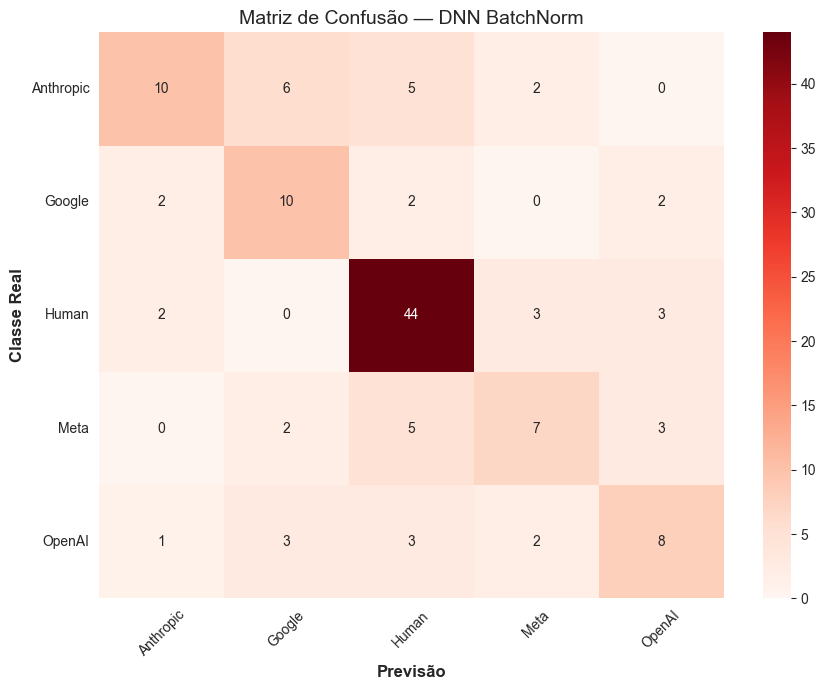


Classification Report — DNN BatchNorm:
              precision    recall  f1-score   support

   Anthropic       0.67      0.43      0.53        23
      Google       0.48      0.62      0.54        16
       Human       0.75      0.85      0.79        52
        Meta       0.50      0.41      0.45        17
      OpenAI       0.50      0.47      0.48        17

    accuracy                           0.63       125
   macro avg       0.58      0.56      0.56       125
weighted avg       0.63      0.63      0.62       125



In [9]:
melhor_model.eval()
with torch.no_grad():
    _, predicted = torch.max(melhor_model(test_input), 1)
y_true = test_labels.cpu().numpy()
y_pred = predicted.cpu().numpy()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsão', fontsize=12, fontweight='bold')
plt.ylabel('Classe Real', fontsize=12, fontweight='bold')
plt.title(f'Matriz de Confusão — {melhor_nome}', fontsize=14)
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

print(f'\nClassification Report — {melhor_nome}:')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

### **7. Guardar o Modelo**

In [10]:
import pickle

os.makedirs('../models', exist_ok=True)

model_path = '../models/pytorch.pth'
torch.save(melhor_model.state_dict(), model_path)
print(f"✅ Pesos guardados em '{model_path}'")

meta = {
    'model_class': melhor_model.__class__.__name__,
    'input_size': input_size,
    'num_classes': num_classes,
    'class_names': list(class_names),
    'transformers': transformers,
    'encoder': encoder,
}

if not is_tabular:
    meta['word2idx'] = word2idx
    meta['max_seq_len'] = MAX_SEQ_LEN
    meta['vocab_size'] = actual_vocab_size
    if melhor_nome == 'BiLSTM + GloVe':
        meta['embed_dim'] = GLOVE_DIM
        meta['hidden_dim'] = HIDDEN_DIM_GLOVE
        meta['embedding_matrix'] = emb_matrix
    else:
        meta['embed_dim'] = EMBED_DIM
        meta['hidden_dim'] = HIDDEN_DIM

meta_path = '../models/pytorch.pkl'
with open(meta_path, 'wb') as f:
    pickle.dump(meta, f)
print(f"✅ Metadados guardados em '{meta_path}'")

print(f'\n📋 Modelo: {meta["model_class"]}')

✅ Pesos guardados em '../models/pytorch.pth'
✅ Metadados guardados em '../models/pytorch.pkl'

📋 Modelo: DNNBatchNorm
